# Pretrain SimMIM + VICReg from MoBY (contrastive self-supervised) weights
VICREG OFF 

## Imports


In [1]:
import os, sys, json, time
from datetime import datetime
from pathlib import Path


In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

## Resources alloc setup

In [3]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
# torch.backends.cudnn.benchmark = True

## Path setup


In [4]:
NB_DIR = Path.cwd().resolve()
NB_NEW = NB_DIR.parent if NB_DIR.parent.name == 'notebooks' else NB_DIR.parents[1]
ROOT   = NB_NEW.parent
for p in (NB_NEW, ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
print('NB_NEW:', NB_NEW)
print('ROOT  :', ROOT)


NB_NEW: /auto/brno2/home/anokhver/thesis/root/notebooks
ROOT  : /auto/brno2/home/anokhver/thesis/root


In [5]:
from training.config import BaseCfg, DataCfg, ModelCfg, TrainCfg, SSLCfg, dump_config
from training.seeding import seed_everything
from training.logging import setup_logger, CSVMetricLogger
from training.data import build_dataloaders, compute_channel_stats
from training.augment import MicroscopyTwoViewTransform, ValSingleViewTransform
from training.masking import random_block_mask, apply_mask
from training.losses import compute_simmim_vicreg_loss, validation_simmim
from training.lr_schedule import param_groups_layer_decay, make_warmup_cosine
from training.checkpoints import save_checkpoint, load_checkpoint, find_latest_checkpoint
from training.sanity_batch import (
    SANITY_TRAIN_INDICES, SANITY_VAL_INDICES,
    fixed_two_view_batch, fixed_single_view_batch, overfit_on_batch,
)
from training.viz import (
    plot_two_views, plot_channel_histograms, plot_recon_panel,
    plot_loss_curves, plot_overfit_curves, plot_embedding_2d,
)
from models.swin import build_swin_encoder, build_simmim_vicreg_heads, count_params
from models.weight_loading import load_pretrained_into_encoder
from clustering.core import extract_pooled_embeddings, reduce_2d

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [6]:
from ssl_training.post_training import (
    build_run_label, eval_recon_batch, reload_best_checkpoint,
    post_training_reconstruction, plot_post_training_curves,
)

## Configuration (GLANCE OVER)

Key differences from the timm-ImageNet variant:

| knob | timm-ImageNet | **MoBY** | reason |
|------|:---:|:---:|--------|
| `init_source` | `timm_imagenet` | **`moby`** | contrastive SSL |
| `base_lr` | 1.5e-4 | **1.0e-4** | MoBY features already SSL-trained |
| `warmup_epochs` | 10 | **15** | objective-switch needs gentler ramp |
| `layer_decay` | 0.90 | **0.85** | protect early MoBY contrastive features |
| `freeze_encoder_epochs` | 1 | **2** | random heads catch up to strong encoder |


In [7]:
RUN_SANITY = True
RUN_OVERFIT = True

In [8]:
base_cfg = BaseCfg(
    seed             = 42,
    output_root      = '../outputs',
    experiment_name  = 'simmim_vicreg_pretrain',
    tag              = 'moby',
    method_name      = 'simmim_vicreg',
    init_source      = 'moby',
    pretrained_ckpt_path = '../../../data/checkpoints/moby_swin_t_300ep_pretrained.pth',
    resume_path      = None,             # set to a .pt file or run dir to resume
    dry_run          = False,
)


In [59]:
data_cfg = DataCfg(
    data_root        = '../../../data/patches_128',
    exclude_patterns = ['KONTROLA'],
    val_split        = 0.10,
    batch_size       = 32, #32,
    num_workers      = 2,
    pin_memory       = True,
    channel_names    = ['pre_synaptic', 'post_synaptic', 'structural'],
)
#TODO depending is I use VISreg or not

In [10]:
model_cfg = ModelCfg(
    in_channels    = 3,
    img_size       = 128,
    feature_size   = 96,
    patch_size     = 2,
    window_size    = 7,
    depths         = (2, 2, 6, 2),
    num_heads      = (3, 6, 12, 24),
    dropout_path_rate = 0.05,
)


In [11]:
train_cfg = TrainCfg(
    epochs                = 200,
    warmup_epochs         = 15,
    base_lr               = 1.0e-4,  # from scratch 1.5e-4
    head_lr               = 1.0e-4, 
    weight_decay          = 0.05,   # AdamW+Swin standard VasoMIM Huang 2026 (medical MIM, same value)
    layer_decay           = 1.0,    # standard Swin/VasoMIM 
    grad_clip_norm        = 5.0,    # SimMIM
    freeze_encoder_epochs = 5,      # standard transfer-learning technique
    save_every_n_epochs   = 25,
    val_metric_key        = 'recon_fg',  # foreground-weighted recon -- whole-image recon is dominated by easy background pixels, so 'ssl_loss' (== recon when w_vicreg=0) makes 'best' gameable by background-only predictors
    val_metric_direction  = 'min',
    encoder_save_name     = 'pretrained_encoder_simmim_vicreg_moby.pt',
)

In [ ]:
ssl_cfg = SSLCfg(
    mask_ratio       = 0.60,   #between 40~75 is standard range
    # H=128 - 2,4,8,16,32,64.
    mask_block_size  = 16,     #  Deepest features: 4×4, each covering 32×32 pixels = 2×2 = 4 mask blocks per feature cell
    loss_kind        = 'l1',
    # VICReg's internal coefficients (25, 25, 1) are paper-canonical (Bardes
    # 2022 Table 7) but their *sum* is ~50x the L1 recon term at w_recon=1.
    # No published joint-MIM recipe sums losses at that ratio (iBOT 1:1,
    # SwinUNETR 1:1:1, CAE 1:2). Keep the (25,25,1) ratio inside VICReg --
    # ratios matter for stability per Bardes Table 7 -- and rescale the
    # whole VICReg branch with ``w_vicreg`` so it matches recon magnitude.
    lambda_sim       = 25.0,
    lambda_std       = 25.0,
    lambda_cov       = 1.0,
    w_recon          = 1.0,
    w_vicreg         = 0.1, #TURNED ON
    # Bardes 2022 Table 12: expander 256 -> 55.9% top-1, 8192 -> 68.6%.
    # Width must be >= encoder dim or BN inside the projector trivially
    # satisfies the variance hinge while the encoder collapses.
    projector_hidden = 2048,
    projector_dim    = 2048,
    # Fourier auxiliary loss (CA-MAE, Kraus 2024) -- masked-tile FFT L1
    w_fourier        = 0.01, 
    # Weighted losses for background vs foreground | unweighted defaults 
    fg_weight_alpha = 0.0, # 0.0 
    fg_weight_tau   = 0.0, # 0.0  
    fg_weight_temp  = 1.0, # 1.0
 )


## Output directory and logger


In [13]:
RUN_TS = datetime.now().strftime('%Y%m%d_%H%M%S')
save_dir = Path(base_cfg.output_root) / f'{base_cfg.experiment_name}_{base_cfg.tag}_{RUN_TS}'
save_dir.mkdir(parents=True, exist_ok=True)
print('save_dir =', save_dir)


save_dir = ../outputs/simmim_vicreg_pretrain_moby_20260513_131211


In [14]:
logger = setup_logger('nb', save_dir / 'run.log')
logger.info(f'experiment = {base_cfg.experiment_name}')
logger.info(f'tag        = {base_cfg.tag}')
logger.info(f'method     = {base_cfg.method_name}')
logger.info(f'init_source= {base_cfg.init_source}')
logger.info(f'save_dir   = {save_dir}')


2026-05-13 13:12:12 | INFO    | experiment = simmim_vicreg_pretrain
2026-05-13 13:12:12 | INFO    | tag        = moby
2026-05-13 13:12:12 | INFO    | method     = simmim_vicreg
2026-05-13 13:12:12 | INFO    | init_source= moby
2026-05-13 13:12:12 | INFO    | save_dir   = ../outputs/simmim_vicreg_pretrain_moby_20260513_131211


In [15]:
dump_config(
    save_dir / 'config.json',
    base=base_cfg, data=data_cfg, model=model_cfg, train=train_cfg, ssl=ssl_cfg,
)
logger.info('config.json written')


2026-05-13 13:12:12 | INFO    | config.json written


## Seed and device


In [16]:
generator = seed_everything(base_cfg.seed)
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f'seed   = {base_cfg.seed}')
logger.info(f'device = {device}')
if device.type == 'cuda':
    name = torch.cuda.get_device_name(0)
    mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    logger.info(f'gpu    = {name}  ({mem:.1f} GB)')


2026-05-13 13:12:14 | INFO    | seed   = 42
2026-05-13 13:12:14 | INFO    | device = cuda
2026-05-13 13:12:14 | INFO    | gpu    = NVIDIA A40  (47.7 GB)


## Data

In [35]:
# Raw dataset
from utils_data.patch_dataset import PatchDataset
raw_dataset = PatchDataset(root=data_cfg.data_root, exclude_patterns=data_cfg.exclude_patterns)
logger.info(f'raw patches = {len(raw_dataset)}')
sample = raw_dataset[0]

logger.info(f'sample shape = {tuple(sample.shape)}  dtype = {sample.dtype}')
assert sample.ndim == 3 and sample.shape[0] == model_cfg.in_channels
assert sample.shape[-1] == model_cfg.img_size


2026-05-13 13:21:14 | INFO    | raw patches = 972
2026-05-13 13:21:14 | INFO    | sample shape = (3, 128, 128)  dtype = torch.float32


In [36]:
# Channel stats (computed on the train split, pre-augmentation)

from torch.utils.data import random_split
n_val   = int(len(raw_dataset) * data_cfg.val_split)
n_train = len(raw_dataset) - n_val
train_subset, val_subset = random_split(raw_dataset, [n_train, n_val], generator=generator)
logger.info(f'split: train={n_train}  val={n_val}')

ch_mean, ch_std = compute_channel_stats(
    train_subset, in_channels=model_cfg.in_channels,
    max_samples=data_cfg.channel_stats_max_samples,
)
for name, m, s in zip(data_cfg.channel_names, ch_mean.tolist(), ch_std.tolist()):
    logger.info(f'  ch[{name:>14s}] mean={m:.5f}  std={s:.5f}')
stats = {'channel_names': list(data_cfg.channel_names), 'mean': ch_mean.tolist(), 'std': ch_std.tolist()}
(save_dir / 'channel_stats.json').write_text(json.dumps(stats, indent=2))


2026-05-13 13:21:15 | INFO    | split: train=875  val=97


channel stats:   0%|          | 0/875 [00:00<?, ?it/s]

2026-05-13 13:22:19 | INFO    |   ch[  pre_synaptic] mean=0.04653  std=0.11731
2026-05-13 13:22:19 | INFO    |   ch[ post_synaptic] mean=0.04310  std=0.11197
2026-05-13 13:22:19 | INFO    |   ch[    structural] mean=0.16223  std=0.14413


266

In [37]:
# Augmentation pipelines
train_transform = MicroscopyTwoViewTransform(ch_mean, ch_std)
val_transform   = ValSingleViewTransform(ch_mean, ch_std)


In [38]:
# DataLoaders
from training.data import TransformedSubset
train_ds = TransformedSubset(train_subset, train_transform)
val_ds   = TransformedSubset(val_subset,   val_transform)
common = dict(
    num_workers=data_cfg.num_workers,
    pin_memory=data_cfg.pin_memory,
    persistent_workers=data_cfg.num_workers > 0,
    prefetch_factor=2 if data_cfg.num_workers > 0 else None,
)
train_loader = DataLoader(train_ds, batch_size=data_cfg.batch_size, shuffle=True,  drop_last=True, **common)
val_loader   = DataLoader(val_ds,   batch_size=data_cfg.batch_size, shuffle=False, **common)
logger.info(f'train batches = {len(train_loader)}  val batches = {len(val_loader)}')


2026-05-13 13:22:20 | INFO    | train batches = 27  val batches = 4


## Checks

In [39]:
if RUN_SANITY or RUN_OVERFIT:
  # Build encoder
  encoder = build_swin_encoder(model_cfg).to(device)
  logger.info(f'encoder params = {count_params(encoder) / 1e6:.2f} M')
  # Load MoBY pretrained weights
  load_summary = load_pretrained_into_encoder(encoder, base_cfg, model_cfg, logger=logger)
  # Verify high coverage: MoBY Swin-T should load ~95%+ of encoder keys
  n_loaded = load_summary['n_loaded']
  n_target = load_summary['n_target_params']
  pct = 100.0 * n_loaded / max(n_target, 1)
  logger.info(f'MoBY coverage: {n_loaded}/{n_target} params loaded ({pct:.1f}%)')
  if load_summary.get('n_shape_mismatch', 0) > 0:
      logger.warning(f'  shape mismatches: {load_summary["shape_mismatch"]}')
  if n_loaded < 0.8 * n_target:
      raise RuntimeError(
              f'Only {pct:.1f}% of encoder loaded from MoBY — expected >=80%. '
          f'Check that the checkpoint is MoBY Swin-T (not DeiT-S — README links are swapped!).'
      )

  random_keys = load_summary.get('random_init', [])
  if random_keys:
      logger.info(f'  random-init keys ({len(random_keys)}):')
      for k in random_keys:
          logger.info(f'    - {k}')
  
  # Build heads (decoder + mask token + projector)
  heads = build_simmim_vicreg_heads(model_cfg, ssl_cfg)
  heads = {k: v.to(device) for k, v in heads.items()}
  logger.info(f'head params = {count_params(heads) / 1e6:.2f} M')


2026-05-13 13:22:20 | INFO    | encoder params = 32.24 M
2026-05-13 13:22:20 | INFO    | [init] loading MoBY checkpoint: ../../../data/checkpoints/moby_swin_t_300ep_pretrained.pth
2026-05-13 13:22:20 | INFO    | [init] source=moby | loaded 178/182 | random_init 4 | shape_mismatch 1 | skipped 9
2026-05-13 13:22:20 | INFO    | MoBY coverage: 178/182 params loaded (97.8%)
2026-05-13 13:22:20 | WARNING |   shape mismatches: [('patch_embed.proj.weight', 'patch_embed.proj.weight', (96, 3, 4, 4), (96, 3, 2, 2))]
2026-05-13 13:22:20 | INFO    |   random-init keys (4):
2026-05-13 13:22:20 | INFO    |     - layers4.0.downsample.norm.bias
2026-05-13 13:22:20 | INFO    |     - layers4.0.downsample.norm.weight
2026-05-13 13:22:20 | INFO    |     - layers4.0.downsample.reduction.weight
2026-05-13 13:22:20 | INFO    |     - patch_embed.proj.weight
2026-05-13 13:22:21 | INFO    | head params = 16.27 M


### Sanity checks

In [40]:
if RUN_SANITY:
  # Sanity check: dataloader yields a two-view pair of the right shape
  batch = next(iter(train_loader))
  assert isinstance(batch, (list, tuple)) and len(batch) == 2, batch
  v1, v2 = batch
  assert v1.shape == v2.shape
  assert v1.shape[1:] == (model_cfg.in_channels, model_cfg.img_size, model_cfg.img_size)
  assert v1.dtype == torch.float32
  assert torch.isfinite(v1).all() and torch.isfinite(v2).all()
  diff = (v1 - v2).abs().mean().item()
  assert diff > 1e-3, f'view1 == view2  (mean abs diff = {diff:.2e})'
  logger.info(f'[ok] views shape={tuple(v1.shape)}  v1-v2 diff={diff:.4f}')


2026-05-13 13:22:22 | INFO    | [ok] views shape=(32, 3, 128, 128)  v1-v2 diff=0.7212


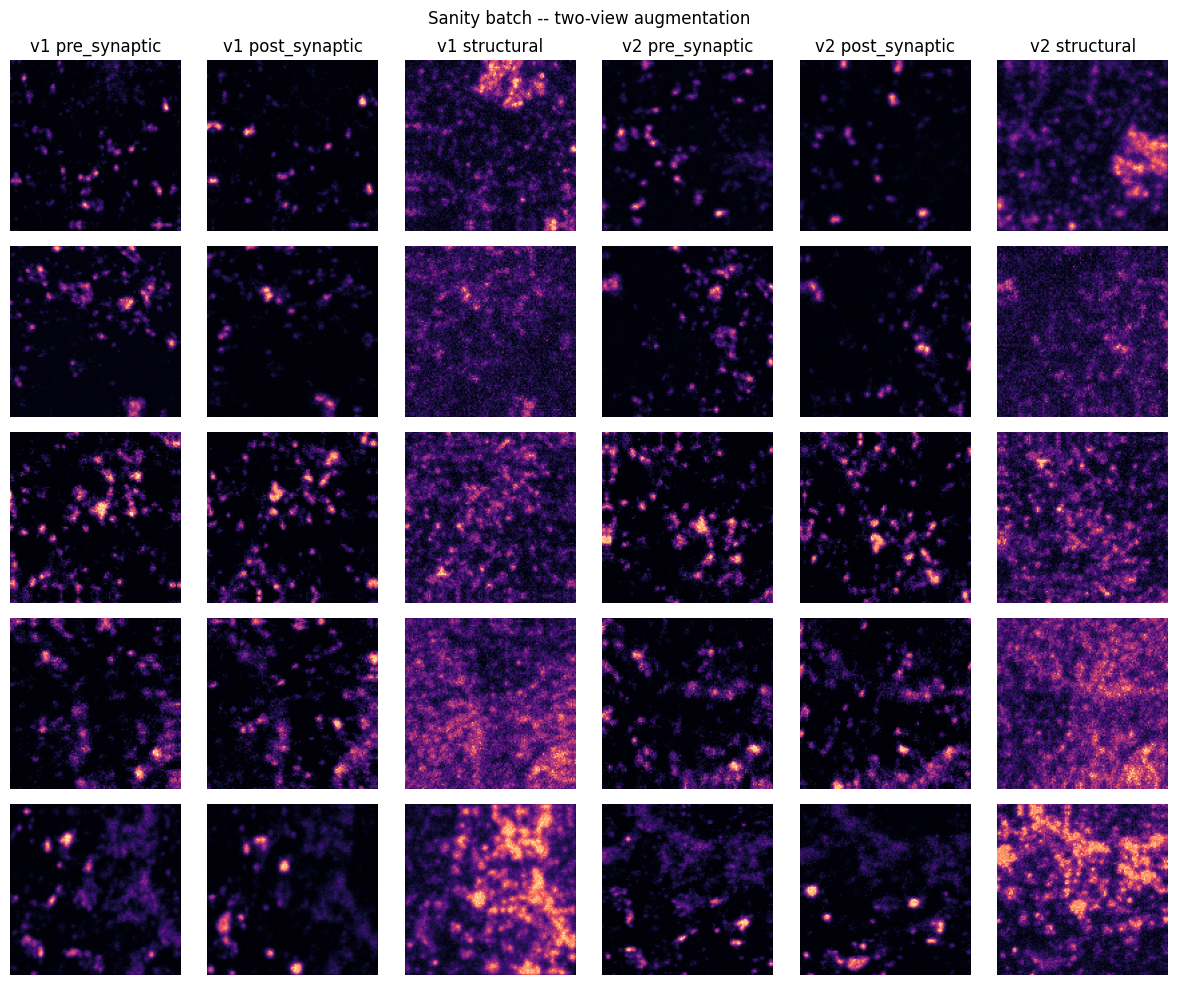

In [41]:
if RUN_SANITY:
    # Sanity check: two-view augmentation visualisation (canonical indices)
    _ = plot_two_views(
        raw_subset=train_subset,
        transform=train_transform,
        indices=SANITY_TRAIN_INDICES,
        channel_names=data_cfg.channel_names,
        suptitle='Sanity batch -- two-view augmentation',
        save_to=save_dir / 'sanity_two_views.png',
    )
    plt.show()


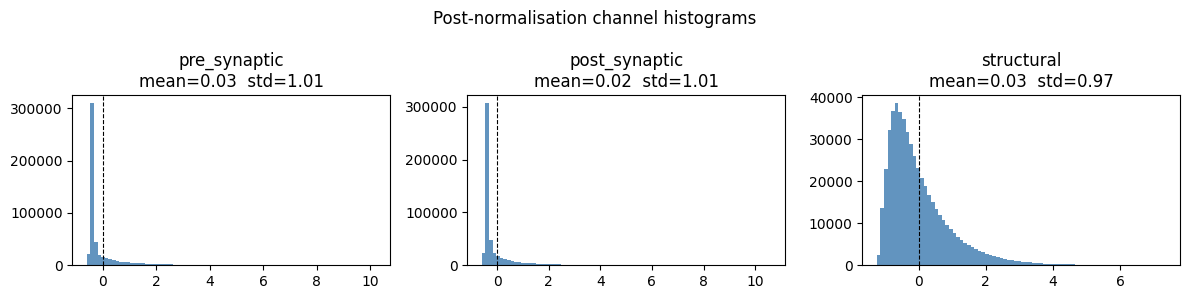

In [42]:
if RUN_SANITY:
    # Sanity check: post-normalisation channel histograms
    _ = plot_channel_histograms(
        v1, channel_names=data_cfg.channel_names,
        save_to=save_dir / 'sanity_histograms.png',
    )
    plt.show()


In [43]:
if RUN_SANITY:
    # Sanity check: encoder forward + per-stage shapes
    encoder.eval()
    with torch.no_grad():
        feats = encoder(v1[:2].to(device).contiguous())
    assert isinstance(feats, list) and len(feats) == len(model_cfg.depths) + 1
    n_stages = len(feats)
    head_idx = ssl_cfg.head_stage_index if ssl_cfg.head_stage_index >= 0 else n_stages + ssl_cfg.head_stage_index
    for i, f in enumerate(feats):
        tag = '  <- heads' if i == head_idx else ''
        logger.info(f'  stage {i}: {tuple(f.shape)}{tag}')
    encoder.train()


2026-05-13 13:22:25 | INFO    |   stage 0: (2, 96, 64, 64)
2026-05-13 13:22:25 | INFO    |   stage 1: (2, 192, 32, 32)
2026-05-13 13:22:25 | INFO    |   stage 2: (2, 384, 16, 16)
2026-05-13 13:22:25 | INFO    |   stage 3: (2, 768, 8, 8)
2026-05-13 13:22:25 | INFO    |   stage 4: (2, 1536, 4, 4)  <- heads


In [44]:
if RUN_SANITY:
    # Sanity check: gradient actually flows through encoder + heads
    encoder.train()
    for h in heads.values(): h.train()
    _opt = torch.optim.AdamW(
        list(encoder.parameters())
        + [p for h in heads.values() for p in h.parameters()],
        lr=1e-4,
    )
    _v1 = v1.to(device); _v2 = v2.to(device)
    _opt.zero_grad(set_to_none=True)
    _loss, _m = compute_simmim_vicreg_loss(encoder, heads, _v1, _v2, ssl_cfg)
    _loss.backward()
    n_grad = sum(1 for p in encoder.parameters() if p.grad is not None)
    n_tot  = sum(1 for _ in encoder.parameters())
    _opt.step()
    del _opt, _loss, _m, _v1, _v2
    logger.info(f'[ok] grad flow: {n_grad}/{n_tot} encoder params got gradients')


2026-05-13 13:22:26 | INFO    | [ok] grad flow: 170/170 encoder params got gradients


### Overfit check

In [45]:
# Build optimizer + scheduler + GradScaler
if RUN_OVERFIT:
    encoder_groups = param_groups_layer_decay(
        encoder,
        base_lr=train_cfg.base_lr,
        weight_decay=train_cfg.weight_decay,
        layer_decay=train_cfg.layer_decay,
    )
    head_params = [p for h in heads.values() for p in h.parameters()]
    head_group  = {'params': head_params, 'lr': train_cfg.head_lr, 'weight_decay': train_cfg.weight_decay}
    optimizer = torch.optim.AdamW(encoder_groups + [head_group], betas=(0.9, 0.999))
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, make_warmup_cosine(train_cfg.warmup_epochs, train_cfg.epochs),
    )
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')


#### Sanity overfit on the canonical train batch

Trains the *real* model on the fixed ``SANITY_TRAIN_INDICES`` for a
small number of steps with a frozen mask. Per the project convention,
the encoder + heads are NOT auto-restored afterwards -- the warm-up
carries into the full training run. Set ``RESET_AFTER_SANITY=True``
if you want a byte-identical pre-overfit state.


In [52]:
if RUN_OVERFIT:
  N_OVERFIT_STEPS  = 1000
  OVERFIT_LR       = 3e-4


In [53]:
if RUN_OVERFIT:
    x1_fixed, x2_fixed, sanity_idx = fixed_two_view_batch(
        train_subset, SANITY_TRAIN_INDICES, train_transform,
        seed=base_cfg.seed + 17,
    )
    x1_fixed = x1_fixed.to(device); x2_fixed = x2_fixed.to(device)
    logger.info(f'sanity batch indices = {sanity_idx}  shape = {tuple(x1_fixed.shape)}')


2026-05-13 13:24:37 | INFO    | sanity batch indices = [3, 4, 50, 200, 400]  shape = (5, 3, 128, 128)


In [54]:
if RUN_OVERFIT:
  torch.manual_seed(base_cfg.seed + 18)
  mask_fixed = random_block_mask(x1_fixed, ssl_cfg.mask_block_size, ssl_cfg.mask_ratio).clone()
  logger.info(f'fixed mask coverage = {mask_fixed.mean().item():.3f}')


2026-05-13 13:24:39 | INFO    | fixed mask coverage = 0.500


In [55]:
if RUN_OVERFIT:
    overfit_result = overfit_on_batch(
        encoder, heads, x1_fixed, x2_fixed, ssl_cfg,
        n_steps=N_OVERFIT_STEPS, lr=OVERFIT_LR,
        grad_clip=train_cfg.grad_clip_norm, fixed_mask=mask_fixed, logger=logger,
    )
else:
    overfit_result = None
    logger.info('overfit sanity skipped (RUN_OVERFIT=False)')


2026-05-13 13:26:19 | INFO    | [overfit] 1000 steps  recon 0.2539 -> 0.0251  (90.1% drop)


#### Plot


2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substituting symbol L from STIXNonUnicode
2026-05-13 13:26:19 [INFO] Substit

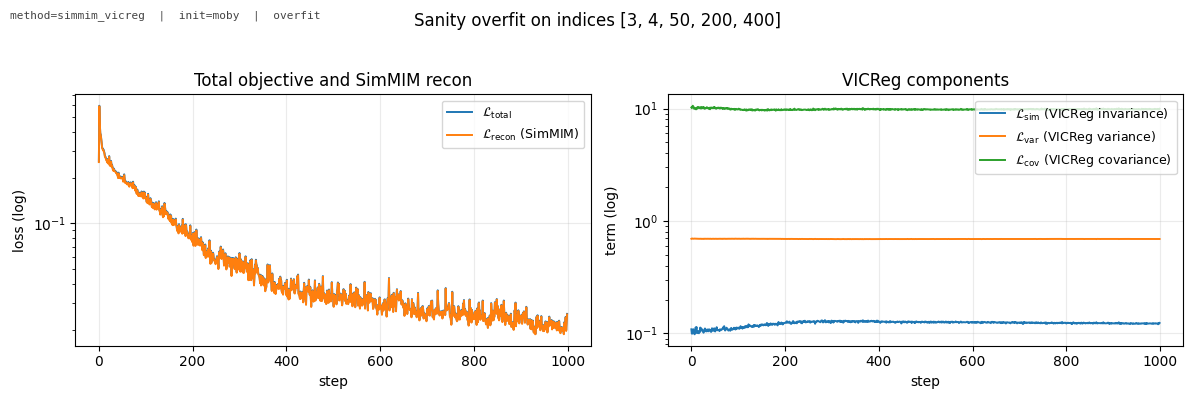

In [56]:
# Overfit-on-batch loss curves
if overfit_result is not None:
    _ = plot_overfit_curves(
        overfit_result['history'],
        suptitle=f'Sanity overfit on indices {sanity_idx}',
        save_to=save_dir / 'sanity_curves_overfit.png',
        run_label=build_run_label(base_cfg, extra='overfit'),
    )
    plt.show()

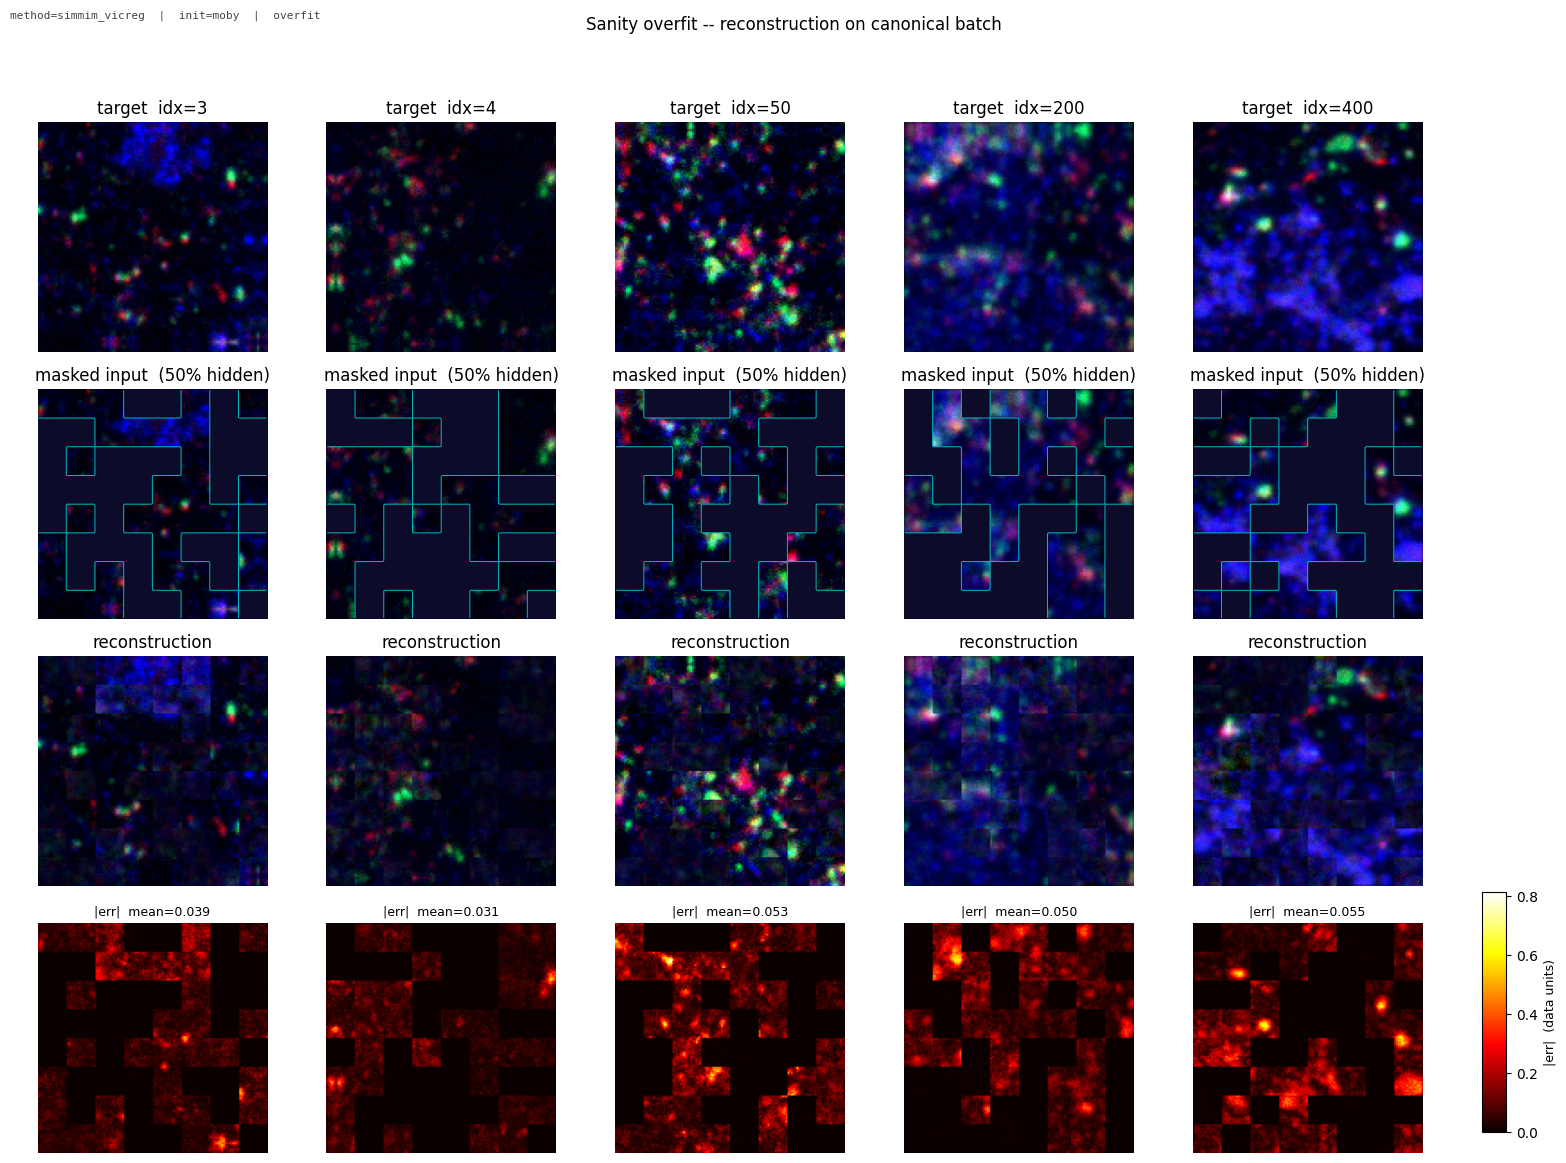

In [57]:
# Overfit-on-batch reconstruction on the canonical batch
if overfit_result is not None:
    rec, v_masked = eval_recon_batch(encoder, heads, x1_fixed, mask_fixed)
    _ = plot_recon_panel(
        x1_fixed, v_masked, rec, mask_fixed, sanity_idx,
        ch_mean=ch_mean, ch_std=ch_std,
        suptitle='Sanity overfit -- reconstruction on canonical batch',
        save_to=save_dir / 'sanity_recon_overfit.png',
        run_label=build_run_label(base_cfg, extra='overfit'),
        channel_names=data_cfg.channel_names,
    )
    plt.show()
    encoder.train()
    for h in heads.values():
        h.train()

## Full training

### Reset for full training

In [ ]:
# Re-seed so the full run is deterministic and independent of the overfit warm-up.
generator = seed_everything(base_cfg.seed)

# Rebuild encoder (re-applies ``base_cfg.init_source``: moby).
encoder = build_swin_encoder(model_cfg).to(device)
load_summary = load_pretrained_into_encoder(encoder, base_cfg, model_cfg, logger=logger)
logger.info(f'[reset] encoder params = {count_params(encoder) / 1e6:.2f} M')


In [ ]:

# Rebuild heads (decoder + mask token + projector).
heads = build_simmim_vicreg_heads(model_cfg, ssl_cfg)
heads = {k: v.to(device) for k, v in heads.items()}
logger.info(f'[reset] head params    = {count_params(heads) / 1e6:.2f} M')


In [ ]:

# Rebuild optimizer + scheduler + GradScaler.
encoder_groups = param_groups_layer_decay(
    encoder,
    base_lr=train_cfg.base_lr,
    weight_decay=train_cfg.weight_decay,
    layer_decay=train_cfg.layer_decay,
)
head_params = [p for h in heads.values() for p in h.parameters()]
head_group  = {'params': head_params, 'lr': train_cfg.head_lr, 'weight_decay': train_cfg.weight_decay}
optimizer = torch.optim.AdamW(encoder_groups + [head_group], betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, make_warmup_cosine(train_cfg.warmup_epochs, train_cfg.epochs),
)
scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')


In [ ]:

# Reset training-state counters.
start_epoch     = 1
best_val_metric = float('inf') if train_cfg.val_metric_direction == 'min' else float('-inf')
best_epoch      = 0
    

In [ ]:

# Re-apply resume logic so it targets a previous full-training checkpoint,
# never the overfit warm-up state.
_resume = base_cfg.resume_path
if _resume is not None:
    p = Path(_resume)
    if p.is_dir():
        p = find_latest_checkpoint(p)
    if p is None or not Path(p).exists():
        logger.warning(f'[reset] resume path {_resume!r} not found -- starting fresh')
    else:
        ckpt = load_checkpoint(
            p, encoder=encoder, heads=heads,
            optimizer=optimizer, scheduler=scheduler, scaler=scaler,
            map_location=device,
        )
        start_epoch     = int(ckpt.get('epoch', 0)) + 1
        best_val_metric = ckpt.get('val_metric', best_val_metric) or best_val_metric
        best_epoch      = int(ckpt.get('epoch', 0))
        logger.info(f'[reset] resumed from {p} (epoch {ckpt.get("epoch")})')
logger.info(f'[reset] start_epoch = {start_epoch}  best_val_metric = {best_val_metric}')


### Resume from a previous interrupted session

Set ``base_cfg.resume_path`` to a checkpoint file (``last.pt``,
``best_model.pt``, ...) or to a directory -- in which case the most
recent checkpoint under it is auto-selected. Leave it ``None`` for a
fresh run.


In [ ]:
start_epoch     = 1
best_val_metric = float('inf') if train_cfg.val_metric_direction == 'min' else float('-inf')
best_epoch      = 0

_resume = base_cfg.resume_path
if _resume is not None:
    p = Path(_resume)
    if p.is_dir():
        p = find_latest_checkpoint(p)
    if p is None or not Path(p).exists():
        logger.warning(f'resume path {_resume!r} not found -- starting fresh')
    else:
        ckpt = load_checkpoint(
            p, encoder=encoder, heads=heads,
            optimizer=optimizer, scheduler=scheduler, scaler=scaler,
            map_location=device,
        )
        start_epoch     = int(ckpt.get('epoch', 0)) + 1
        best_val_metric = ckpt.get('val_metric', best_val_metric) or best_val_metric
        best_epoch      = int(ckpt.get('epoch', 0))
        logger.info(f'resumed from {p} (epoch {ckpt.get("epoch")})')
logger.info(f'start_epoch = {start_epoch}  best_val_metric = {best_val_metric}')


### CSV metric logger


In [ ]:
csv_fields = [
    'epoch', 'phase',
    'train_loss', 'val_metric',
    'lr_encoder', 'lr_head',
    'epoch_time_s', 'train_time_s', 'val_time_s',
    'best_val_metric', 'best_epoch',
    'grad_norm_mean', 'grad_norm_max',
    'train_recon', 'train_fourier', 'train_sim', 'train_std', 'train_cov', 'train_vicreg',
    'val_recon', 'val_recon_fg', 'val_fourier', 'val_std', 'val_cov',
]
csv_logger = CSVMetricLogger(save_dir / 'metrics.csv', csv_fields)


### Training-loop helpers


In [ ]:
# Gradual unfreezing schedule (top-down). Each tuple is
# (start_epoch, list_of_groups_unfrozen_from_this_epoch_onwards).
# Groups: 'random' (random-init keys), 'layers1'..'layers4', 'patch_embed'.
# Heads (decoder, mask_token, projector) live outside `encoder` and always train.
# Designed so the full network is open by epoch 15 (== train_cfg.warmup_epochs).
UNFREEZE_SCHEDULE = [
    (1,  ['random', 'layers4']),
    (3,  ['random', 'layers4']),
    (6,  ['random', 'layers4', 'layers3']),
    (9,  ['random', 'layers4', 'layers3', 'layers2']),
    (12, ['random', 'layers4', 'layers3', 'layers2', 'layers1']),
    (15, ['random', 'layers4', 'layers3', 'layers2', 'layers1', 'patch_embed']),
]

_PHASE_TAG = {
    1: 'rand+L4', 2: 'rand+L4', 3: 'rand+L4..L3',
    4: 'rand+L4..L2', 5: 'rand+L4..L1', 6: 'full',
}


In [ ]:
def _param_in_group(name, group, random_init_names):
    if group == 'random':
        return name in random_init_names
    return name.startswith(group)  # 'patch_embed', 'layers1'..'layers4'

def apply_unfreeze_schedule(enc, epoch, schedule, random_init_names):
    active = []
    for start, groups in schedule:
        if epoch >= start:
            active = groups
    active_set = set(active)
    for name, p in enc.named_parameters():
        p.requires_grad = any(
            _param_in_group(name, g, random_init_names) for g in active_set
        )
    return active

def set_train(enc, hds, training):
    enc.train(training)
    for h in hds.values():
        h.train(training)

def heads_iter_lrs(opt):
    enc_lrs  = [g['lr'] for g in opt.param_groups if 'stage' in g]
    head_lrs = [g['lr'] for g in opt.param_groups if 'stage' not in g]
    return (max(enc_lrs) if enc_lrs else 0.0,
            head_lrs[0] if head_lrs else 0.0)

def all_trainable_params(enc, hds):
    return ([p for p in enc.parameters() if p.requires_grad]
            + [p for h in hds.values() for p in h.parameters() if p.requires_grad])


### Full training loop


In [ ]:
train_losses, val_history, lr_history = [], [], []
total_t0 = time.time()


In [ ]:
def train_one_epoch(encoder, heads, train_loader, optimizer, scaler,
                    ssl_cfg, train_cfg, device, *, epoch, total_epochs, phase):
    """One training epoch. Returns (loss, components, grad_norms, seconds)."""
    set_train(encoder, heads, True)
    running, grads = 0.0, []
    comp_accum = {}
    t0 = time.time()
    pbar = tqdm(train_loader, desc=f'ep {epoch}/{total_epochs} [{phase}]', leave=False)
    for v1_b, v2_b in pbar:
        v1_b = v1_b.to(device, non_blocking=True)
        v2_b = v2_b.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device.type, enabled=device.type == 'cuda'):
            loss, _m = compute_simmim_vicreg_loss(encoder, heads, v1_b, v2_b, ssl_cfg)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        gn = torch.nn.utils.clip_grad_norm_(
            all_trainable_params(encoder, heads),
            max_norm=train_cfg.grad_clip_norm,
        )
        grads.append(gn.item())
        scaler.step(optimizer)
        scaler.update()
        running += loss.item()
        for _k, _v in _m.items():
            comp_accum[_k] = comp_accum.get(_k, 0.0) + float(_v)
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    n_tb = max(1, len(train_loader))
    train_loss = running / n_tb
    train_components = {k: v / n_tb for k, v in comp_accum.items()}
    return train_loss, train_components, grads, time.time() - t0


def validate_one_epoch(encoder, heads, val_loader, ssl_cfg, train_cfg, device):
    """One validation pass. Returns (metrics_dict, val_metric_scalar, seconds)."""
    set_train(encoder, heads, False)
    val_accum = {}
    n_vb = 0
    t0 = time.time()
    with torch.no_grad():
        for v_b in val_loader:
            if isinstance(v_b, (list, tuple)):
                v_b = v_b[0]
            v_b = v_b.to(device, non_blocking=True)
            vm = validation_simmim(encoder, heads, v_b, ssl_cfg)
            for k, v in vm.items():
                val_accum[k] = val_accum.get(k, 0.0) + float(v)
            n_vb += 1
        for k in val_accum:
            val_accum[k] /= max(1, n_vb)
    val_metric = val_accum[train_cfg.val_metric_key]
    return val_accum, val_metric, time.time() - t0

In [ ]:
import json

_better = (lambda new, best: new < best) if train_cfg.val_metric_direction == 'min' else (lambda new, best: new > best)



In [ ]:
if base_cfg.dry_run:
    logger.info('dry_run=True -- skipping full training loop')
else:
    random_init_names = set(load_summary.get('random_init', []))
    for epoch in range(start_epoch, train_cfg.epochs + 1):
        active = apply_unfreeze_schedule(encoder, epoch, UNFREEZE_SCHEDULE, random_init_names)
        phase_idx = max(
            (i for i, (start, _) in enumerate(UNFREEZE_SCHEDULE, 1) if epoch >= start),
            default=0,
        )
        phase = _PHASE_TAG.get(phase_idx, f'phase{phase_idx}')

        # ── Train ──
        train_loss, train_components, grads, train_time = train_one_epoch(
            encoder, heads, train_loader, optimizer, scaler,
            ssl_cfg, train_cfg, device,
            epoch=epoch, total_epochs=train_cfg.epochs, phase=phase,
        )
        scheduler.step()

        # ── Validate ──
        val_accum, val_metric, val_time = validate_one_epoch(
            encoder, heads, val_loader, ssl_cfg, train_cfg, device,
        )

        # ── Metrics & checkpointing ──
        enc_lr, head_lr = heads_iter_lrs(optimizer)
        epoch_time = train_time + val_time
        gmean = sum(grads) / max(1, len(grads))
        gmax  = max(grads) if grads else 0.0

        improved = ''
        if _better(val_metric, best_val_metric):
            best_val_metric = val_metric
            best_epoch      = epoch
            improved        = ' *best*'
            save_checkpoint(
                save_dir / 'best_model.pt',
                encoder=encoder, heads=heads,
                optimizer=optimizer, scheduler=scheduler, scaler=scaler,
                epoch=epoch, val_metric=val_metric, train_loss=train_loss,
                extra={'all_val_metrics': val_accum,
                       'channel_mean': ch_mean.tolist(),
                       'channel_std':  ch_std.tolist()},
            )
        save_checkpoint(
            save_dir / 'last.pt',
            encoder=encoder, heads=heads,
            optimizer=optimizer, scheduler=scheduler, scaler=scaler,
            epoch=epoch, val_metric=val_metric, train_loss=train_loss,
            extra={'channel_mean': ch_mean.tolist(),
                   'channel_std':  ch_std.tolist()},
        )
        if train_cfg.save_every_n_epochs and epoch % train_cfg.save_every_n_epochs == 0:
            save_checkpoint(
                save_dir / f'epoch_{epoch:04d}.pt',
                encoder=encoder, heads=heads,
                optimizer=optimizer, scheduler=scheduler, scaler=scaler,
                epoch=epoch, val_metric=val_metric, train_loss=train_loss,
                extra={'channel_mean': ch_mean.tolist(),
                       'channel_std':  ch_std.tolist()},
            )

        # ── History & logging ──
        train_losses.append(train_loss)
        val_history.append(val_accum)
        lr_history.append((enc_lr, head_lr))
        csv_logger.log(dict(
            epoch=epoch, phase=phase,
            train_loss=train_loss, val_metric=val_metric,
            lr_encoder=enc_lr, lr_head=head_lr,
            epoch_time_s=epoch_time, train_time_s=train_time, val_time_s=val_time,
            best_val_metric=best_val_metric, best_epoch=best_epoch,
            grad_norm_mean=gmean, grad_norm_max=gmax,
            train_recon=train_components.get('recon'),
            train_fourier=train_components.get('fourier'),
            train_sim=train_components.get('sim'),
            train_std=train_components.get('std'),
            train_cov=train_components.get('cov'),
            train_vicreg=train_components.get('vicreg'),
            val_recon=val_accum.get('recon'),
            val_recon_fg=val_accum.get('recon_fg'),
            val_fourier=val_accum.get('fourier'),
            val_std=val_accum.get('std'),
            val_cov=val_accum.get('cov'),
        ))
        logger.info(
            f'ep {epoch:3d}/{train_cfg.epochs} [{phase}]  '
            f'train={train_loss:.5f}  val[{train_cfg.val_metric_key}]={val_metric:.5f}  '
            f'recon(t/v)={train_components.get("recon",0):.4f}/{val_accum.get("recon",0):.4f}  recon_fg(t/v)={train_components.get("recon_fg",0):.4f}/{val_accum.get("recon_fg",0):.4f}  '
            f'std(t/v)={train_components.get("std",0):.4f}/{val_accum.get("std",0):.4f}  '
            f'lr(enc/head)={enc_lr:.2e}/{head_lr:.2e}  t={epoch_time:.1f}s  gn={gmean:.2f}{improved}'
        )

    # ── Post-loop cleanup ──
    csv_logger.close()
    logger.info(f'total training time = {(time.time() - total_t0) / 60:.1f} min')

## After training plotting

In [ ]:
# Reload best checkpoint and build a run-identifying label for the figures.
ckpt = reload_best_checkpoint(save_dir, encoder, heads, device, logger=logger)
run_label = build_run_label(
    base_cfg,
    epoch=(ckpt or {}).get('epoch'),
    val_metric=(ckpt or {}).get('val_metric'),
)

In [58]:
# Reconstruction on the canonical TRAIN sanity batch
_ = post_training_reconstruction(
    encoder, heads, train_subset, train_transform, ssl_cfg,
    ch_mean=ch_mean, ch_std=ch_std, save_dir=save_dir,
    base_seed=base_cfg.seed, view='train',
    run_label=run_label, channel_names=data_cfg.channel_names,
    device=device,
)

NameError: name 'run_label' is not defined

In [ ]:
# Reconstruction on the canonical VAL sanity patches (no aug)
_ = post_training_reconstruction(
    encoder, heads, val_subset, val_transform, ssl_cfg,
    ch_mean=ch_mean, ch_std=ch_std, save_dir=save_dir,
    base_seed=base_cfg.seed, view='val',
    run_label=run_label, channel_names=data_cfg.channel_names,
    device=device,
)

In [ ]:
# Training curves (total / SimMIM recon / VICReg components / LR schedule)
_ = plot_post_training_curves(save_dir, run_label=run_label, logger=logger)

## Save encoder-only checkpoint


In [ ]:
best_path = save_dir / 'best_model.pt'
if best_path.exists():
    src = torch.load(best_path, map_location=device, weights_only=False)
    enc_path = save_dir / train_cfg.encoder_save_name
    torch.save({
        'encoder_state_dict': src['encoder_state_dict'],
        'channel_mean':       src.get('channel_mean', ch_mean.tolist()),
        'channel_std':        src.get('channel_std',  ch_std.tolist()),
        'epoch':              src.get('epoch'),
        'val_metric':         src.get('val_metric'),
        'init_source':        base_cfg.init_source,
        'method_name':        base_cfg.method_name,
    }, enc_path)
    logger.info(f'encoder saved to {enc_path}')
else:
    logger.warning('no best_model.pt -- nothing to export')


## Full-image reconstruction (sliding window)

Reassemble one of the source microscopy images from its 128x128 patches, run the trained encoder + decoder over a sliding-window grid (50%% overlap by default; `stride = patch_size * (1 - overlap)`), then average masked reconstructions across overlapping windows. Same masking recipe as training (`mask_block_size`, `mask_ratio` from `ssl_cfg`), same z-score + de-z-score. Each pixel ends up reconstructed under several different random masks coming from different windows, so the averaged output is a fair full-image-scale post-training sanity rather than the single-patch panel above.

In [ ]:
# Full-image SimMIM reconstruction with proper sliding-window averaging.
# - Reassembles a full image from its 128x128 tiles (data.reassemble).
# - Slides a model_cfg.img_size window with `overlap` fraction of overlap.
# - For every window: z-score, SimMIM block-mask, encode, decode.
# - Averages reconstructions (and the masked-input views) across overlapping
#   windows, de-z-scores back to [0, 1] for display.
# - Saves: post_recon_fullimage.png and post_recon_fullimage.npz.
import numpy as np
from data.reassemble import reassemble_image, list_image_indices

FULL_IMAGE_INDEX = None  # None -> first non-excluded image
FULL_OVERLAP     = 0.5   # 50% overlap -> stride = patch_size / 2
FULL_BATCH       = 16


@torch.no_grad()
def full_image_sliding_recon(
    encoder, heads, full_image, *,
    patch_size, mask_block_size, mask_ratio, head_stage_index,
    ch_mean, ch_std, device,
    overlap=0.5, batch_size=16, seed=0,
):
    """Sliding-window SimMIM reconstruction on one (C, H, W) full image."""
    encoder.eval()
    for h in heads.values():
        h.eval()

    C, H, W = full_image.shape
    stride = max(1, int(patch_size * (1.0 - overlap)))

    ch_mean_np = np.asarray(ch_mean.cpu(), dtype=np.float32).reshape(-1, 1, 1)
    ch_std_np  = np.asarray(ch_std.cpu(),  dtype=np.float32).reshape(-1, 1, 1)

    # Reflect-pad so windows tile evenly even when H/W is not a multiple of stride.
    pad_h = (stride - (H - patch_size) % stride) % stride if H > patch_size else patch_size - H
    pad_w = (stride - (W - patch_size) % stride) % stride if W > patch_size else patch_size - W
    padded = np.pad(full_image, ((0, 0), (0, pad_h), (0, pad_w)), mode='reflect')
    pH, pW = padded.shape[1], padded.shape[2]

    acc_recon  = np.zeros((C, pH, pW), dtype=np.float64)
    acc_masked = np.zeros((C, pH, pW), dtype=np.float64)
    acc_mask   = np.zeros((pH, pW),    dtype=np.float64)
    count      = np.zeros((pH, pW),    dtype=np.float64)

    positions = [(y, x)
                 for y in range(0, pH - patch_size + 1, stride)
                 for x in range(0, pW - patch_size + 1, stride)]

    torch.manual_seed(seed)
    mu = ch_mean.view(1, -1, 1, 1).to(device)
    sd = ch_std.view(1, -1, 1, 1).to(device)

    for i in tqdm(range(0, len(positions), batch_size), desc='sliding'):
        batch_pos = positions[i:i + batch_size]
        patches = [(padded[:, y:y + patch_size, x:x + patch_size] - ch_mean_np) / ch_std_np
                   for y, x in batch_pos]
        view = torch.from_numpy(np.stack(patches)).float().to(device)

        mask = random_block_mask(view, mask_block_size, mask_ratio)
        v_masked = apply_mask(view, mask, heads['mask_token'])
        z = encoder(v_masked.contiguous())[head_stage_index]
        recon = heads['decoder'](z).float()

        recon01  = (recon    * sd + mu).clamp(0, 1).cpu().numpy()
        masked01 = (v_masked * sd + mu).clamp(0, 1).cpu().numpy()
        mask_np  = mask.cpu().numpy()[:, 0]

        for j, (y, x) in enumerate(batch_pos):
            acc_recon [:, y:y + patch_size, x:x + patch_size] += recon01[j]
            acc_masked[:, y:y + patch_size, x:x + patch_size] += masked01[j]
            acc_mask  [   y:y + patch_size, x:x + patch_size] += mask_np[j]
            count     [   y:y + patch_size, x:x + patch_size] += 1.0

    cs = np.maximum(count, 1.0)
    full_recon  = (acc_recon  / cs)[:, :H, :W].astype(np.float32)
    full_masked = (acc_masked / cs)[:, :H, :W].astype(np.float32)
    mask_freq   = (acc_mask   / cs)[:H, :W].astype(np.float32)
    return full_recon, full_masked, mask_freq, len(positions)


In [ ]:
idxs = list_image_indices(data_cfg.data_root, exclude_patterns=data_cfg.exclude_patterns)
img_idx = idxs[0] if FULL_IMAGE_INDEX is None else FULL_IMAGE_INDEX
full_image, _records = reassemble_image(
    data_cfg.data_root, img_idx,
    exclude_patterns=data_cfg.exclude_patterns,
)
logger.info(f'full image idx={img_idx}  shape={tuple(full_image.shape)}  '
            f'source={_records[0]["source_image"]}')

full_recon, full_masked, mask_freq, n_windows = full_image_sliding_recon(
    encoder, heads, full_image,
    patch_size=model_cfg.img_size,
    mask_block_size=ssl_cfg.mask_block_size,
    mask_ratio=ssl_cfg.mask_ratio,
    head_stage_index=ssl_cfg.head_stage_index,
    ch_mean=ch_mean, ch_std=ch_std,
    device=device,
    overlap=FULL_OVERLAP,
    batch_size=FULL_BATCH,
    seed=base_cfg.seed + 31,
)

err = np.abs(full_recon - full_image).mean(0)
logger.info(
    f'full-image recon: windows={n_windows}  '
    f'stride={int(model_cfg.img_size * (1 - FULL_OVERLAP))}px  '
    f'mean|err|={float(err.mean()):.4f}  max|err|={float(err.max()):.4f}'
)

np.savez_compressed(
    save_dir / 'post_recon_fullimage.npz',
    image_index=np.array(img_idx),
    full_image=full_image,
    full_recon=full_recon,
    full_masked=full_masked,
    mask_freq=mask_freq,
    overlap=np.float32(FULL_OVERLAP),
)


In [ ]:
C, H, W = full_image.shape
ncols = max(3, C)
fig, axes = plt.subplots(4, ncols, figsize=(4 * ncols, 16), squeeze=False)
for r in range(4):
    for c in range(ncols):
        axes[r, c].axis('off')

for ci, name in enumerate(data_cfg.channel_names):
    axes[0, ci].imshow(full_image[ci],  cmap='magma', vmin=0, vmax=1)
    axes[0, ci].set_title(f'target  {name}')
    axes[1, ci].imshow(full_masked[ci], cmap='magma', vmin=0, vmax=1)
    axes[1, ci].set_title(f'masked input (avg)  {name}')
    axes[2, ci].imshow(full_recon[ci],  cmap='magma', vmin=0, vmax=1)
    axes[2, ci].set_title(f'reconstruction  {name}')

axes[3, 0].imshow(np.transpose(np.clip(full_image, 0, 1), (1, 2, 0)))
axes[3, 0].set_title('target  RGB')
axes[3, 1].imshow(np.transpose(np.clip(full_recon, 0, 1), (1, 2, 0)))
axes[3, 1].set_title('reconstruction  RGB')
err_vmax = max(float(err.max()), 1e-6)
err_im = axes[3, 2].imshow(err, cmap='hot', vmin=0, vmax=err_vmax)
axes[3, 2].set_title(f'|err|  mean={float(err.mean()):.3f}')
fig.colorbar(err_im, ax=axes[3, 2], fraction=0.046, pad=0.02)

mask_pct = int(ssl_cfg.mask_ratio * 100)
fig.suptitle(
    f'POST: full-image sliding-window reconstruction  '
    f'(img={img_idx}, stride={int(model_cfg.img_size * (1 - FULL_OVERLAP))}px, '
    f'mask={mask_pct}% blk={ssl_cfg.mask_block_size}, '
    f'windows={n_windows})'
)
try:
    if run_label:
        fig.text(0.01, 0.985, run_label, ha='left', va='top', fontsize=8,
                 color='#444', family='DejaVu Sans Mono')
except NameError:
    pass
fig.tight_layout(rect=(0, 0, 0.97, 0.97))
fig.savefig(save_dir / 'post_recon_fullimage.png', dpi=120, bbox_inches='tight')
plt.show()
